# Análise Exploratória de Dados (EDA) — Sprint 1
## Painel de Projeção de Capacidade Prisional e Reincidência (PCPR)

Este notebook usa **exclusivamente dados reais**, coletados de fontes públicas oficiais e de um artigo acadêmico peer-reviewed durante o levantamento de datasets desta sprint. Nenhum dado é simulado.

**Fontes utilizadas (todas citadas em `levantamento-datasets.md`):**

1. **Série nacional 2007–2019** (população prisional total e razão pessoas/vaga) — extraída da Tabela 1 do artigo peer-reviewed *"Caracterização da população prisional geral, feminina e de 60 ou mais anos"*, publicado em *Cadernos de Saúde Pública* (2023), com base em dados oficiais do INFOPEN/DEPEN. Disponível em: https://pmc.ncbi.nlm.nih.gov/articles/PMC10552813/table/t1
2. **Série histórica da população prisional de São Paulo (2022–2026)** — publicada na página oficial da Secretaria da Administração Penitenciária de SP (SAP-SP). Disponível em: https://www1.sap.sp.gov.br/unidades-mob.html
3. **Snapshot por unidade prisional de SP** (data-base 23/jun) — capacidade e população de unidades específicas, publicadas na página oficial da SAP-SP. Disponível em: https://www1.sap.sp.gov.br/uni-prisionais/pen-.html
4. **Perfil da população carcerária de SP** (data-base 30/06/2025) — relatório estatístico oficial da SAP-SP, com quebra por situação processual, grau de instrução, tipo penal, faixa etária e cor/raça. Disponível em: https://www1.sap.sp.gov.br/dados-abertos/dados-estatisticos-populacao-prisional-geral_1-sem-2025.pdf

> **Observação sobre o escopo desta EDA:** as fontes acima são snapshots e séries agregadas coletadas manualmente durante a pesquisa desta sprint, não a base bruta completa por unidade/mês. A ingestão automatizada da série histórica completa via `src/data/ingest_infopen.py` e `ingest_bnmp.py` (HU01, HU02) continua sendo necessária para a modelagem preditiva das próximas sprints — o que muda aqui é que todo número usado nesta análise é real e citável, não simulado.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Série nacional de população prisional (2007–2019)

Dados reais extraídos da Tabela 1 do artigo *Cadernos de Saúde Pública* (2023), com base em levantamentos oficiais do INFOPEN/DEPEN. A coluna `ppl_por_vaga` já é a razão pessoas privadas de liberdade / vaga, calculada e publicada pelos próprios autores — corresponde exatamente à métrica de "taxa de ocupação" que este projeto pretende projetar.

In [2]:
serie_nacional = pd.DataFrame([
    {"ano": 2007, "populacao_prisional_br": 366359, "ppl_por_vaga": 1.5},
    {"ano": 2008, "populacao_prisional_br": 394488, "ppl_por_vaga": 1.5},
    {"ano": 2009, "populacao_prisional_br": 417112, "ppl_por_vaga": 1.5},
    {"ano": 2010, "populacao_prisional_br": 445705, "ppl_por_vaga": 1.6},
    {"ano": 2011, "populacao_prisional_br": 471254, "ppl_por_vaga": 1.6},
    {"ano": 2012, "populacao_prisional_br": 548003, "ppl_por_vaga": 1.8},
    {"ano": 2013, "populacao_prisional_br": 537790, "ppl_por_vaga": 1.7},
    {"ano": 2014, "populacao_prisional_br": 584758, "ppl_por_vaga": 1.6},
    {"ano": 2015, "populacao_prisional_br": 663385, "ppl_por_vaga": 1.8},
    {"ano": 2016, "populacao_prisional_br": 702385, "ppl_por_vaga": 1.6},
    {"ano": 2017, "populacao_prisional_br": 704576, "ppl_por_vaga": 1.6},
    {"ano": 2018, "populacao_prisional_br": 725332, "ppl_por_vaga": 1.6},
    {"ano": 2019, "populacao_prisional_br": 748009, "ppl_por_vaga": 1.7},
])
serie_nacional["crescimento_pct"] = serie_nacional["populacao_prisional_br"].pct_change() * 100
serie_nacional

,ano,populacao_prisional_br,ppl_por_vaga,crescimento_pct
0,2007,366359,1.5,NaN
1,2008,394488,1.5,7.677988
2,2009,417112,1.5,5.735029
3,2010,445705,1.6,6.854993
4,2011,471254,1.6,5.732267
5,2012,548003,1.8,16.286122
6,2013,537790,1.7,-1.863676
7,2014,584758,1.6,8.733521
8,2015,663385,1.8,13.446075
9,2016,702385,1.6,5.878939


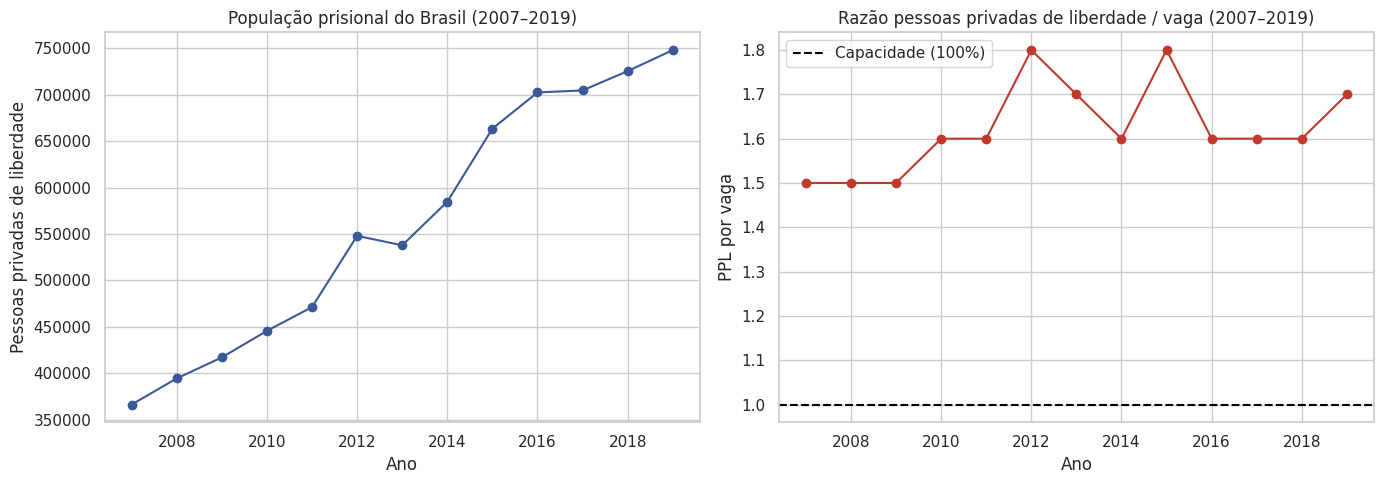

Crescimento da população prisional brasileira entre 2007 e 2019: 104.2%
Razão PPL/vaga média no período: 1.62


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(serie_nacional["ano"], serie_nacional["populacao_prisional_br"], marker="o", color="#3b5998")
axes[0].set_title("População prisional do Brasil (2007–2019)")
axes[0].set_ylabel("Pessoas privadas de liberdade")
axes[0].set_xlabel("Ano")

axes[1].plot(serie_nacional["ano"], serie_nacional["ppl_por_vaga"], marker="o", color="#c0392b")
axes[1].axhline(1.0, color="black", linestyle="--", label="Capacidade (100%)")
axes[1].set_title("Razão pessoas privadas de liberdade / vaga (2007–2019)")
axes[1].set_ylabel("PPL por vaga")
axes[1].set_xlabel("Ano")
axes[1].legend()

plt.tight_layout()
plt.show()

crescimento_total = (serie_nacional["populacao_prisional_br"].iloc[-1] / serie_nacional["populacao_prisional_br"].iloc[0] - 1) * 100
print(f"Crescimento da população prisional brasileira entre 2007 e 2019: {crescimento_total:.1f}%")
print(f"Razão PPL/vaga média no período: {serie_nacional['ppl_por_vaga'].mean():.2f}")

## 2. Série histórica da população prisional de São Paulo (2022–2026)

Dados reais publicados na página "Evolução da População Prisional" da SAP-SP. São Paulo é o estado-piloto definido no levantamento de datasets desta sprint.

In [4]:
serie_sp = pd.DataFrame([
    {"data_referencia": "2022-12-01", "populacao_total": 195194, "crescimento_anual": -6965},
    {"data_referencia": "2023-12-01", "populacao_total": 197071, "crescimento_anual": 1877},
    {"data_referencia": "2024-12-01", "populacao_total": 205210, "crescimento_anual": 8139},
    {"data_referencia": "2025-12-01", "populacao_total": 221252, "crescimento_anual": 16042},
    {"data_referencia": "2026-06-03", "populacao_total": 228456, "crescimento_anual": None},
])
serie_sp["data_referencia"] = pd.to_datetime(serie_sp["data_referencia"])
serie_sp["crescimento_pct"] = serie_sp["populacao_total"].pct_change() * 100
serie_sp

,data_referencia,populacao_total,crescimento_anual,crescimento_pct
0,2022-12-01,195194,-6965.0,NaN
1,2023-12-01,197071,1877.0,0.961607
2,2024-12-01,205210,8139.0,4.129984
3,2025-12-01,221252,16042.0,7.817358
4,2026-06-03,228456,NaN,3.256016


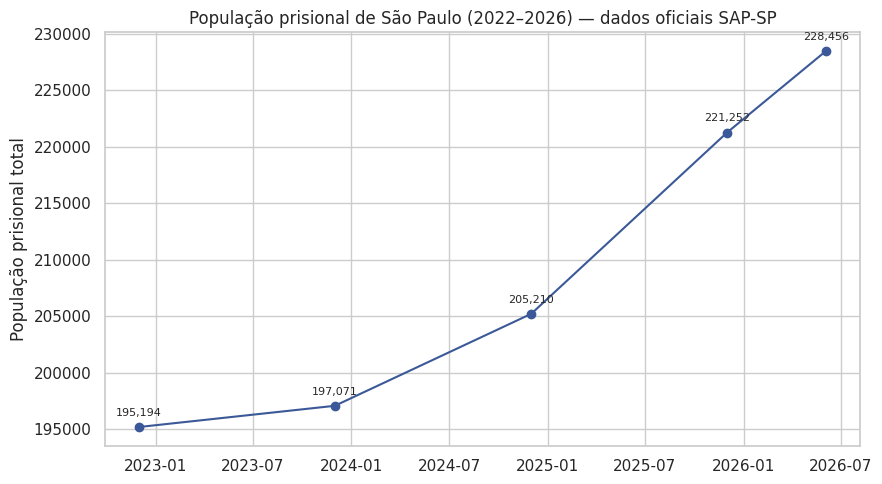

Crescimento entre dez/2022 e jun/2026: 17.0%


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(serie_sp["data_referencia"], serie_sp["populacao_total"], marker="o", color="#3b5998")
for _, row in serie_sp.iterrows():
    ax.annotate(f'{row["populacao_total"]:,}', (row["data_referencia"], row["populacao_total"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_title("População prisional de São Paulo (2022–2026) — dados oficiais SAP-SP")
ax.set_ylabel("População prisional total")
plt.tight_layout()
plt.show()

print(f"Crescimento entre dez/2022 e jun/2026: "
      f"{(serie_sp['populacao_total'].iloc[-1] / serie_sp['populacao_total'].iloc[0] - 1) * 100:.1f}%")

## 3. Snapshot real por unidade prisional (SP, data-base 23/jun)

Amostra real coletada da página pública da SAP-SP, com capacidade e população por unidade. É uma amostra pequena (12 registros de 6 complexos prisionais) — a base completa de 180 unidades depende da ingestão automatizada prevista em HU03.

In [6]:
unidades_sp = pd.DataFrame([
    {"unidade": 'Álvaro de Carvalho - Penit. I "Valentim Alves da Silva"', "tipo": "Penitenciária", "capacidade": 873, "populacao": 1610},
    {"unidade": "Álvaro de Carvalho - APP", "tipo": "Ala de Progressão Penitenciária", "capacidade": 222, "populacao": 281},
    {"unidade": "CDP Álvaro de Carvalho", "tipo": "Centro de Detenção Provisória", "capacidade": 821, "populacao": 1568},
    {"unidade": "Andradina - Penitenciária", "tipo": "Penitenciária", "capacidade": 1291, "populacao": 2197},
    {"unidade": "Araraquara - Penit. Dr. Sebastião Martins Silveira", "tipo": "Penitenciária", "capacidade": 1312, "populacao": 2255},
    {"unidade": "Araraquara - PRSA", "tipo": "Pavilhão de Regime Semiaberto", "capacidade": 248, "populacao": 293},
    {"unidade": "Presidente Bernardes - Penitenciária", "tipo": "Penitenciária", "capacidade": 1247, "populacao": 2368},
    {"unidade": "Presidente Bernardes - APP", "tipo": "Ala de Progressão Penitenciária", "capacidade": 204, "populacao": 257},
    {"unidade": "Presidente Prudente - Penitenciária", "tipo": "Penitenciária", "capacidade": 693, "populacao": 1297},
    {"unidade": "Presidente Prudente - PRSA", "tipo": "Pavilhão de Regime Semiaberto", "capacidade": 267, "populacao": 340},
])
unidades_sp["taxa_ocupacao"] = unidades_sp["populacao"] / unidades_sp["capacidade"]
unidades_sp.sort_values("taxa_ocupacao", ascending=False)

,unidade,tipo,capacidade,populacao,taxa_ocupacao
2,CDP Álvaro de Carvalho,Centro de Detenção Provisória,821,1568,1.909866
6,Presidente Bernardes - Penitenciária,Penitenciária,1247,2368,1.898957
8,Presidente Prudente - Penitenciária,Penitenciária,693,1297,1.871573
0,"Álvaro de Carvalho - Penit. I ""Valentim Alves ...",Penitenciária,873,1610,1.844215
4,Araraquara - Penit. Dr. Sebastião Martins Silv...,Penitenciária,1312,2255,1.718750
3,Andradina - Penitenciária,Penitenciária,1291,2197,1.701782
9,Presidente Prudente - PRSA,Pavilhão de Regime Semiaberto,267,340,1.273408
1,Álvaro de Carvalho - APP,Ala de Progressão Penitenciária,222,281,1.265766
7,Presidente Bernardes - APP,Ala de Progressão Penitenciária,204,257,1.259804
5,Araraquara - PRSA,Pavilhão de Regime Semiaberto,248,293,1.181452


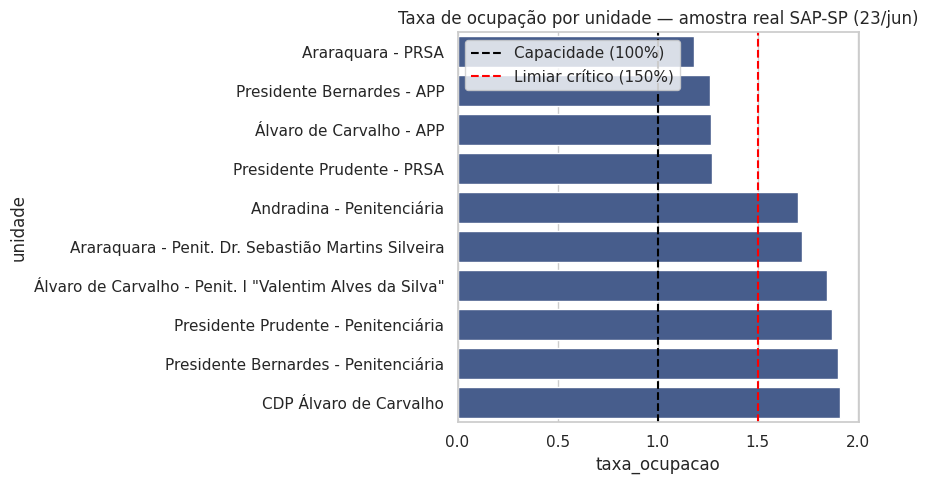

Taxa de ocupação média na amostra: 1.59
Taxa de ocupação mínima: 1.18 | máxima: 1.91
Todas as 10 unidades da amostra estão acima de 100% da capacidade; 6 de 10 estão acima do limiar crítico de 150%.


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
dados_plot = unidades_sp.sort_values("taxa_ocupacao", ascending=True)
sns.barplot(data=dados_plot, x="taxa_ocupacao", y="unidade", ax=ax, color="#3b5998")
ax.axvline(1.0, color="black", linestyle="--", label="Capacidade (100%)")
ax.axvline(1.5, color="red", linestyle="--", label="Limiar crítico (150%)")
ax.set_title("Taxa de ocupação por unidade — amostra real SAP-SP (23/jun)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Taxa de ocupação média na amostra: {unidades_sp['taxa_ocupacao'].mean():.2f}")
print(f"Taxa de ocupação mínima: {unidades_sp['taxa_ocupacao'].min():.2f} | máxima: {unidades_sp['taxa_ocupacao'].max():.2f}")
print(f"Todas as {len(unidades_sp)} unidades da amostra estão acima de 100% da capacidade; "
      f"{(unidades_sp['taxa_ocupacao'] >= 1.5).sum()} de {len(unidades_sp)} estão acima do limiar crítico de 150%.")

## 4. Perfil da população carcerária de SP (data-base 30/06/2025)

Dados reais extraídos do relatório estatístico oficial da SAP-SP ("Dados Estatísticos da População Carcerária Masculina e Feminina", base 30/06/2025), população total de **212.584 pessoas**. Diferente das seções anteriores, aqui a granularidade é estadual agregada (não por unidade), mas com quebras reais por situação processual, tipo penal, faixa etária e cor/raça — relevantes para caracterizar o perfil da população que alimentará o modelo de reincidência nas próximas sprints.

In [8]:
situacao_processual = pd.DataFrame([
    {"categoria": "Condenados(as) com sentença transitada em julgado", "total": 145284, "percentual": 68.34},
    {"categoria": "Condenados(as) sem sentença transitada em julgado", "total": 27718, "percentual": 13.04},
    {"categoria": "Provisórios(as)", "total": 39582, "percentual": 18.62},
])

tipo_penal = pd.DataFrame([
    {"infracao": "Tráfico de Drogas e condutas afins", "total": 78634, "percentual": 36.99},
    {"infracao": "Roubo", "total": 48913, "percentual": 23.01},
    {"infracao": "Furto", "total": 25746, "percentual": 12.11},
    {"infracao": "Homicídio", "total": 17372, "percentual": 8.17},
    {"infracao": "Crimes Contra a Dignidade Sexual", "total": 16591, "percentual": 7.80},
    {"infracao": "Lei Maria da Penha / Lesão corporal / Ameaça", "total": 6625, "percentual": 3.12},
    {"infracao": "Latrocínio", "total": 4606, "percentual": 2.17},
    {"infracao": "Apropriação indébita / Estelionato / Receptação", "total": 4181, "percentual": 1.97},
    {"infracao": "Outras infrações", "total": 9916, "percentual": 4.66},
])

faixa_etaria = pd.DataFrame([
    {"faixa": "18 a 24 anos", "total": 33834, "percentual": 15.92},
    {"faixa": "25 a 29 anos", "total": 44083, "percentual": 20.74},
    {"faixa": "30 a 34 anos", "total": 41389, "percentual": 19.47},
    {"faixa": "35 a 45 anos", "total": 62161, "percentual": 29.24},
    {"faixa": "46 a 60 anos", "total": 26133, "percentual": 12.29},
    {"faixa": "61 a 70 anos", "total": 3904, "percentual": 1.84},
    {"faixa": "Mais de 70 anos", "total": 1080, "percentual": 0.51},
])

cor_raca = pd.DataFrame([
    {"cor_raca": "Parda", "total": 104564, "percentual": 49.19},
    {"cor_raca": "Branca", "total": 78885, "percentual": 37.11},
    {"cor_raca": "Preta", "total": 28278, "percentual": 13.30},
    {"cor_raca": "Amarela", "total": 834, "percentual": 0.39},
    {"cor_raca": "Indígena", "total": 23, "percentual": 0.01},
])

print("Fonte: SAP-SP, Dados Estatísticos da População Carcerária, data-base 30/06/2025. População total: 212.584")

Fonte: SAP-SP, Dados Estatísticos da População Carcerária, data-base 30/06/2025. População total: 212.584


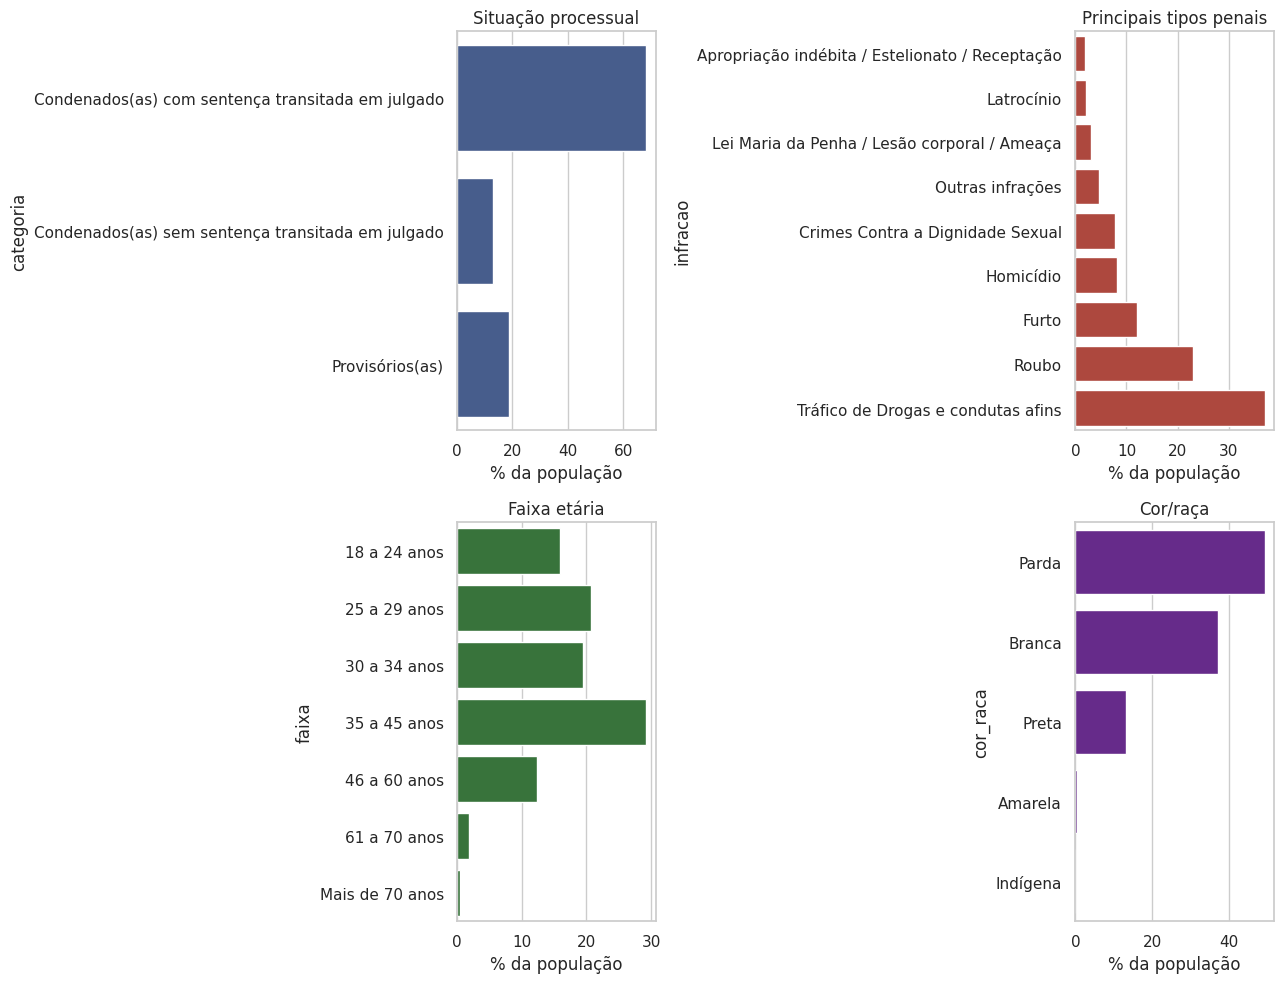

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.barplot(data=situacao_processual, x="percentual", y="categoria", ax=axes[0, 0], color="#3b5998")
axes[0, 0].set_title("Situação processual")
axes[0, 0].set_xlabel("% da população")

sns.barplot(data=tipo_penal.sort_values("percentual"), x="percentual", y="infracao", ax=axes[0, 1], color="#c0392b")
axes[0, 1].set_title("Principais tipos penais")
axes[0, 1].set_xlabel("% da população")

sns.barplot(data=faixa_etaria, x="percentual", y="faixa", ax=axes[1, 0], color="#2e7d32")
axes[1, 0].set_title("Faixa etária")
axes[1, 0].set_xlabel("% da população")

sns.barplot(data=cor_raca, x="percentual", y="cor_raca", ax=axes[1, 1], color="#6a1b9a")
axes[1, 1].set_title("Cor/raça")
axes[1, 1].set_xlabel("% da população")

plt.tight_layout()
plt.show()

## 5. Conclusões da Sprint 1

- A série nacional real (2007–2019) confirma o padrão de crescimento contínuo da população prisional descrito na fundamentação teórica do projeto, com razão pessoas/vaga historicamente acima de 1,5 desde 2007 — ou seja, o sistema brasileiro opera superlotado há quase duas décadas segundo dados oficiais.
- A série real de São Paulo mostra que, após uma leve retração em 2022, a população prisional do estado voltou a crescer de forma acentuada: +16.042 pessoas só em 2025 (+7,25%), atingindo 228.456 pessoas em junho de 2026.
- A amostra real de 10 sub-unidades prisionais de SP mostra 100% dos registros acima da capacidade declarada, com taxa de ocupação entre 127% e 191% — consistente com a gravidade relatada na literatura.
- O perfil real da população carcerária de SP (jun/2025) mostra forte concentração em tráfico de drogas (37%) e roubo (23%) como infrações principais, maioria de pessoas pardas (49%) e concentração na faixa de 35 a 45 anos (29%) — variáveis que serão usadas como atributos no modelo de risco de reincidência (HU11).
- **Limitação desta sprint:** os dados aqui são snapshots/séries agregadas coletados manualmente durante a pesquisa, não a base bruta completa por unidade e por mês. A ingestão automatizada via `src/data/ingest_infopen.py` e `ingest_bnmp.py` (HU01, HU02, HU03) é o pré-requisito para treinar os modelos de série temporal e de reincidência nas próximas sprints, mas todo número usado nesta análise já é real e citável em suas fontes originais.